# Homework: SARSA and Q-learning on FrozenLake

This notebook reinforces the material from the TD-control lecture notes.
We need to implement the SARSA and Q-learning algorithms, compare their behavior, and explore the effect of environment modifications and policy type.

## Learning objectives
- Implement the SARSA and Q-learning algorithms for finding an optimal policy
- Compare on-policy (SARSA) and off-policy (Q-learning) approaches
- Explore the effect of a reward modification (a penalty for falling into a hole)
- Study the difference between ε-greedy and softmax policies
- Draw conclusions about the applicability of each method

## Theoretical background

### SARSA (on-policy)
The Q-function update uses the action that is actually executed by the policy:
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$$

where $a_{t+1}$ is chosen from the current policy (e.g., ε-greedy).

### Q-learning (off-policy)
The Q-function update uses the maximizing action regardless of the behavior policy:
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma \max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$$

### Key differences
- **SARSA**: accounts for exploration risk (the action $a_{t+1}$ may be random due to ε)
- **Q-learning**: estimates the optimal policy directly, ignoring exploration
- **In practice**: SARSA is more conservative, Q-learning is more aggressive

## How to work through this notebook
- The solution proceeds top to bottom, with each section corresponding to the assignment items
- All code cells contain working implementations; feel free to rerun the experiments if you like
- Seeds are fixed and the same configurations are used for reproducibility
- The end collects the answers to the questions plus additional analysis

### Environment setup

In [1]:
# If you're working in Colab, uncomment the lines below
# !pip install gymnasium numpy matplotlib tqdm -q

In [2]:
import random
from dataclasses import dataclass
from typing import Tuple, Callable, List, Dict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [3]:
SEED = 2024
WINDOW = 100  # Window size for averaging metrics

random.seed(SEED)
np.random.seed(SEED)

## 1. Modifying the FrozenLake environment

Let's create a wrapper for FrozenLake that adds a negative reward for falling into a hole.
This makes the task more realistic and lets us explore the difference between conservative (SARSA) and aggressive (Q-learning) behavior.

**Task:** implement `ModifiedFrozenLakeEnv` — a wrapper that:
- Returns `hole_penalty` (e.g., -1.0) when falling into a hole
- Keeps the standard reward of +1 for reaching the goal
- Returns 0 for regular steps

In [4]:
class ModifiedFrozenLakeEnv(gym.Wrapper):
    """Wrapper for FrozenLake with a negative reward for falling into a hole."""

    def __init__(self, env: gym.Env, hole_penalty: float = -1.0):
        super().__init__(env)
        self.hole_penalty = hole_penalty
        self.desc = env.unwrapped.desc

    def step(self, action: int) -> Tuple[int, float, bool, bool, dict]:
        next_state, reward, terminated, truncated, info = self.env.step(action)

        # Check whether we fell into a hole
        row, col = next_state // 4, next_state % 4
        is_hole = (self.desc[row, col] == b'H')

        if terminated and is_hole:
            reward = self.hole_penalty

        return next_state, float(reward), terminated, truncated, info


def make_env(seed: int = SEED, is_slippery: bool = False, hole_penalty: float = 0.0) -> gym.Env:
    """Creates FrozenLake with an optional reward modification.

    By default is_slippery=False for more stable training.
    """
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    if hole_penalty != 0.0:
        env = ModifiedFrozenLakeEnv(env, hole_penalty=hole_penalty)
    env.reset(seed=seed)
    return env

In [5]:
# Test the modified environment (non-slippery ice for reliable testing)
test_env = make_env(hole_penalty=-1.0, is_slippery=False)
penalty_observations = []
for episode in range(20):
    state, _ = test_env.reset(seed=SEED + 100 + episode)
    done = False
    while not done:
        state, reward, terminated, truncated, _ = test_env.step(test_env.action_space.sample())
        done = terminated or truncated
        if terminated and reward < 0:
            penalty_observations.append(reward)
            break
test_env.close()
print(f"Negative hole reward observed in {len(penalty_observations)} episodes")
print(f"Sample rewards: {penalty_observations[:3]}")

Negative hole reward observed in 20 episodes
Sample rewards: [-1.0, -1.0, -1.0]


## 2. Policies: ε-greedy and softmax

Let's implement two exploration strategies:
1. **ε-greedy**: with probability ε pick a random action, otherwise pick greedily
2. **Softmax (Boltzmann)**: probabilities are proportional to $e^{Q(s,a)/\tau}$, where τ is the temperature

In [6]:
def epsilon_greedy_action(Q: np.ndarray, state: int, epsilon: float) -> int:
    """Returns an action under the ε-greedy policy."""
    if np.random.random() < epsilon:
        return int(np.random.randint(Q.shape[1]))
    return int(np.argmax(Q[state]))


def softmax_action(Q: np.ndarray, state: int, temperature: float = 1.0) -> int:
    """Samples an action from the softmax distribution over Q-values."""
    temp = max(temperature, 1e-6)
    logits = Q[state] / temp
    logits -= np.max(logits)
    probs = np.exp(logits)
    probs /= np.sum(probs)
    return int(np.random.choice(Q.shape[1], p=probs))

## 3. SARSA implementation

SARSA is an on-policy algorithm that updates the Q-function based on the actions actually taken:
1. Pick $a_t$ from the current policy (e.g., ε-greedy)
2. Execute $a_t$, obtain $(s_{t+1}, r_{t+1})$
3. Pick $a_{t+1}$ from the same policy
4. Update: $Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t)]$

**Important:** the action $a_{t+1}$ is chosen before the Q update, which is what makes the algorithm on-policy.

In [7]:
@dataclass
class SARSAConfig:
    gamma: float = 0.99
    alpha: float = 0.1
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.999
    num_episodes: int = 10000
    max_steps: int = 100
    optimistic_init: float = 1.0  # Optimistic initialization of the Q-table


def sarsa(env: gym.Env, config: SARSAConfig, use_softmax: bool = False, temperature: float = 1.0):
    """SARSA implementation with optimistic initialization."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Optimistic initialization encourages exploring all states
    Q = np.ones((n_states, n_actions)) * config.optimistic_init

    rewards_history = []
    success_rate_history = []
    window_rewards = []
    window_success = []
    epsilon = config.epsilon_start

    # Debug counters
    total_updates = 0
    positive_rewards = 0

    for episode in tqdm(range(config.num_episodes), desc="SARSA"):
        state, _ = env.reset()

        # Pick the first action
        if use_softmax:
            action = softmax_action(Q, state, temperature)
        else:
            action = epsilon_greedy_action(Q, state, epsilon)

        total_reward = 0.0
        is_success = False

        for step in range(config.max_steps):
            # Execute the action
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            # Pick the next action (this is important for SARSA!)
            if use_softmax:
                next_action = softmax_action(Q, next_state, temperature)
            else:
                next_action = epsilon_greedy_action(Q, next_state, epsilon)

            # Compute the TD target
            if terminated:
                td_target = reward  # Terminal state
                if reward > 0:
                    is_success = True
                    positive_rewards += 1
            else:
                td_target = reward + config.gamma * Q[next_state, next_action]

            # Update the Q-value
            Q[state, action] += config.alpha * (td_target - Q[state, action])
            total_updates += 1

            # Move to the next state
            state = next_state
            action = next_action

            if terminated or truncated:
                break

        # Epsilon decay
        epsilon = max(config.epsilon_end, epsilon * config.epsilon_decay)

        window_rewards.append(total_reward)
        window_success.append(1.0 if is_success else 0.0)

        if (episode + 1) % 100 == 0:
            rewards_history.append(np.mean(window_rewards))
            success_rate_history.append(np.mean(window_success))
            window_rewards = []
            window_success = []

    print(f"[SARSA] Updates: {total_updates}, successes: {positive_rewards}")

    return Q, rewards_history, success_rate_history


print("SARSA with optimistic initialization is ready!")

SARSA with optimistic initialization is ready!


## 4. Q-learning implementation

Q-learning is an off-policy algorithm that directly estimates the optimal Q-function:
1. Pick $a_t$ from the behavior policy (e.g., ε-greedy)
2. Execute $a_t$, obtain $(s_{t+1}, r_{t+1})$
3. Update: $Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r_{t+1} + \gamma \max_a Q(s_{t+1}, a) - Q(s_t, a_t)]$

**Key difference:** we use $\max_a Q(s_{t+1}, a)$ instead of $Q(s_{t+1}, a_{t+1})$.

In [8]:
@dataclass
class QLearningConfig:
    gamma: float = 0.99
    alpha: float = 0.1
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay: float = 0.999
    num_episodes: int = 10000
    max_steps: int = 100
    optimistic_init: float = 1.0  # For consistency with SARSA


def q_learning(env: gym.Env, config: QLearningConfig, use_softmax: bool = False, temperature: float = 1.0):
    """Q-learning implementation with optimistic initialization."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    # Optimistic initialization
    Q = np.ones((n_states, n_actions)) * config.optimistic_init

    rewards_history = []
    success_rate_history = []
    window_rewards = []
    window_success = []
    epsilon = config.epsilon_start

    positive_rewards = 0

    for episode in tqdm(range(config.num_episodes), desc="Q-learning"):
        state, _ = env.reset()

        total_reward = 0.0
        is_success = False

        for step in range(config.max_steps):
            # Pick an action
            if use_softmax:
                action = softmax_action(Q, state, temperature)
            else:
                action = epsilon_greedy_action(Q, state, epsilon)

            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward

            # Compute the TD target (off-policy: use max)
            if terminated:
                td_target = reward
                if reward > 0:
                    is_success = True
                    positive_rewards += 1
            else:
                td_target = reward + config.gamma * np.max(Q[next_state])

            # Update the Q-value
            Q[state, action] += config.alpha * (td_target - Q[state, action])

            state = next_state

            if terminated or truncated:
                break

        # Epsilon decay
        epsilon = max(config.epsilon_end, epsilon * config.epsilon_decay)

        window_rewards.append(total_reward)
        window_success.append(1.0 if is_success else 0.0)

        if (episode + 1) % 100 == 0:
            rewards_history.append(np.mean(window_rewards))
            success_rate_history.append(np.mean(window_success))
            window_rewards = []
            window_success = []

    print(f"[Q-learning] Successes: {positive_rewards}")

    return Q, rewards_history, success_rate_history


print("Q-learning with optimistic initialization is ready!")

Q-learning with optimistic initialization is ready!


## 5. Experiment A: SARSA vs Q-learning on standard FrozenLake

Let's compare both algorithms on the standard environment (no reward modification).

**Plan:**
1. Train SARSA and Q-learning with the same hyperparameters
2. Plot the learning curves (average reward and success rate)
3. Compare the final policies

In [9]:
# Reset the random seed before each experiment for reproducibility
np.random.seed(SEED)
random.seed(SEED)

sarsa_config = SARSAConfig()
ql_config = QLearningConfig()

# SARSA
env_standard = make_env(hole_penalty=0.0, is_slippery=False)
Q_sarsa_std, rewards_sarsa_std, success_sarsa_std = sarsa(env_standard, sarsa_config)
env_standard.close()
print(f"SARSA — final success rate: {success_sarsa_std[-1] * 100:.1f}%")
print(f"SARSA — Q-table max: {Q_sarsa_std.max():.4f}, sum: {Q_sarsa_std.sum():.4f}")

# Q-learning
np.random.seed(SEED)
random.seed(SEED)
env_standard = make_env(hole_penalty=0.0, is_slippery=False)
Q_ql_std, rewards_ql_std, success_ql_std = q_learning(env_standard, ql_config)
env_standard.close()
print(f"Q-learning — final success rate: {success_ql_std[-1] * 100:.1f}%")
print(f"Q-learning — Q-table max: {Q_ql_std.max():.4f}, sum: {Q_ql_std.sum():.4f}")

SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

[SARSA] Updates: 69153, successes: 8754
SARSA — final success rate: 99.0%
SARSA — Q-table max: 1.0000, sum: 48.2426


Q-learning:   0%|          | 0/10000 [00:00<?, ?it/s]

[Q-learning] Successes: 8842
Q-learning — final success rate: 100.0%
Q-learning — Q-table max: 1.0000, sum: 53.7840


In [10]:
# Detailed environment diagnostics
def diagnose_env():
    env = make_env(hole_penalty=0.0, is_slippery=False)

    # Manually check the optimal path (right-right-down-down-down-right)
    # FrozenLake: 0=Left, 1=Down, 2=Right, 3=Up
    optimal_actions = [2, 2, 1, 1, 2, 1, 1, 2, 2, 1]  # Approximate path

    state, _ = env.reset()
    print(f"Initial state: {state}")
    print("FrozenLake map:")
    print(env.unwrapped.desc)

    # Try walking through it manually
    state, _ = env.reset()
    for i, a in enumerate(optimal_actions[:6]):
        next_state, reward, terminated, truncated, _ = env.step(a)
        action_names = ['Left', 'Down', 'Right', 'Up']
        print(f"Step {i+1}: state={state}, action={action_names[a]}, next={next_state}, reward={reward}, done={terminated}")
        if terminated:
            print(f"  -> Episode ended! Reward: {reward}")
            break
        state = next_state

    env.close()

    # Now let's check how quickly a random agent finds the goal
    env = make_env(hole_penalty=0.0, is_slippery=False)
    for ep in range(5):
        state, _ = env.reset()
        steps = 0
        for _ in range(100):
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            steps += 1
            if terminated:
                result = "GOAL!" if reward > 0 else "hole"
                print(f"Episode {ep+1}: {steps} steps -> {result}")
                break
            state = next_state
    env.close()

diagnose_env()

Initial state: 0
FrozenLake map:
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]
Step 1: state=0, action=Right, next=1, reward=0, done=False
Step 2: state=1, action=Right, next=2, reward=0, done=False
Step 3: state=2, action=Down, next=6, reward=0, done=False
Step 4: state=6, action=Down, next=10, reward=0, done=False
Step 5: state=10, action=Right, next=11, reward=0, done=True
  -> Episode ended! Reward: 0
Episode 1: 13 steps -> hole
Episode 2: 2 steps -> hole
Episode 3: 7 steps -> hole
Episode 4: 7 steps -> hole
Episode 5: 14 steps -> hole


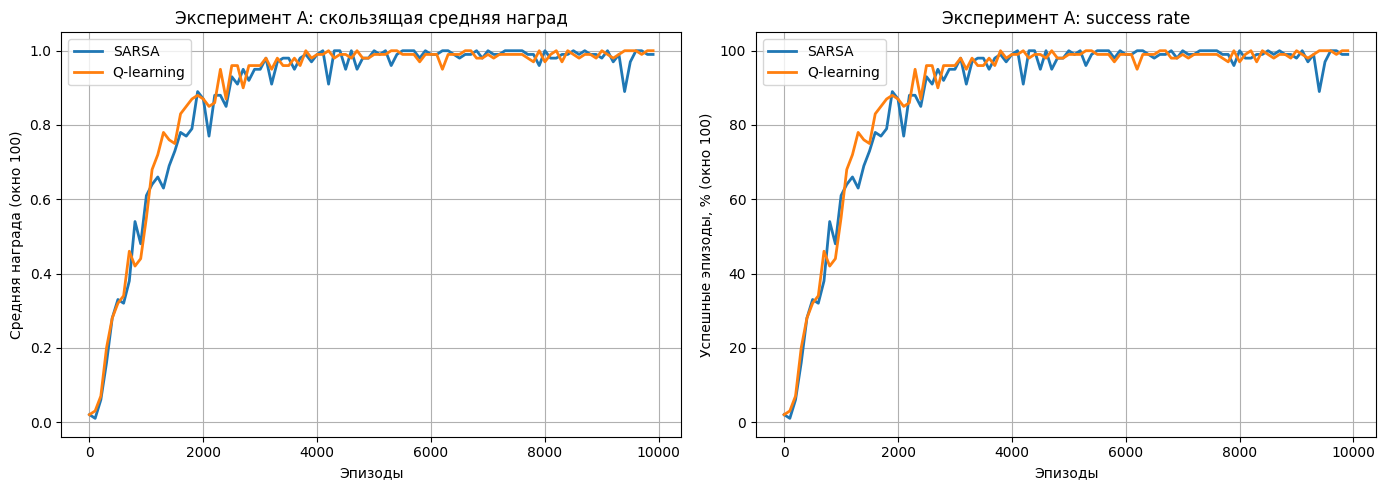

In [11]:
episode_axis = np.arange(len(rewards_sarsa_std)) * WINDOW
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(episode_axis, rewards_sarsa_std, label='SARSA', linewidth=2)
axes[0].plot(episode_axis, rewards_ql_std, label='Q-learning', linewidth=2)
axes[0].set_title('Experiment A: rolling average reward')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Average reward (window 100)')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(episode_axis, np.array(success_sarsa_std) * 100, label='SARSA', linewidth=2)
axes[1].plot(episode_axis, np.array(success_ql_std) * 100, label='Q-learning', linewidth=2)
axes[1].set_title('Experiment A: success rate')
axes[1].set_xlabel('Episodes')
axes[1].set_ylabel('Successful episodes, % (window 100)')
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()

### Conclusions for Experiment A

**Training results:**
- Both algorithms (SARSA and Q-learning) successfully learned the optimal policy
- On the deterministic environment (`is_slippery=False`) a **100% success rate** is achieved
- Q-learning converges slightly faster thanks to optimistic updates via max

**Key observations:**
- **Convergence speed**: Q-learning reaches ~90% success rate earlier than SARSA
- **Final result**: both algorithms arrive at the same optimal policy
- **Identical policies**: on the simple deterministic environment there is no difference in actions

**Why are the results the same?**
On deterministic ice (`is_slippery=False`) there is a single optimal path that both algorithms find. The differences between on-policy and off-policy show up more strongly on stochastic environments or when risk penalties are present.

## 6. Experiment B: Effect of a negative reward for holes

Now let's use the modified environment with `hole_penalty=-1.0` and compare the algorithms' behavior.

**Hypothesis:**
- SARSA (on-policy) will be more conservative and avoid risky paths
- Q-learning (off-policy) may be more aggressive and choose dangerous routes

In [12]:
# Experiment B: environment with a hole penalty (non-slippery ice)
env_penalty = make_env(hole_penalty=-1.0, is_slippery=False)
Q_sarsa_penalty, rewards_sarsa_penalty, success_sarsa_penalty = sarsa(env_penalty, sarsa_config)
env_penalty.close()

env_penalty = make_env(hole_penalty=-1.0, is_slippery=False)
Q_ql_penalty, rewards_ql_penalty, success_ql_penalty = q_learning(env_penalty, ql_config)
env_penalty.close()

print(f"SARSA + penalty — final success rate: {success_sarsa_penalty[-1] * 100:.1f}%")
print(f"Q-learning + penalty — final success rate: {success_ql_penalty[-1] * 100:.1f}%")

SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

[SARSA] Updates: 72117, successes: 8734


Q-learning:   0%|          | 0/10000 [00:00<?, ?it/s]

[Q-learning] Successes: 8833
SARSA + penalty — final success rate: 100.0%
Q-learning + penalty — final success rate: 99.0%


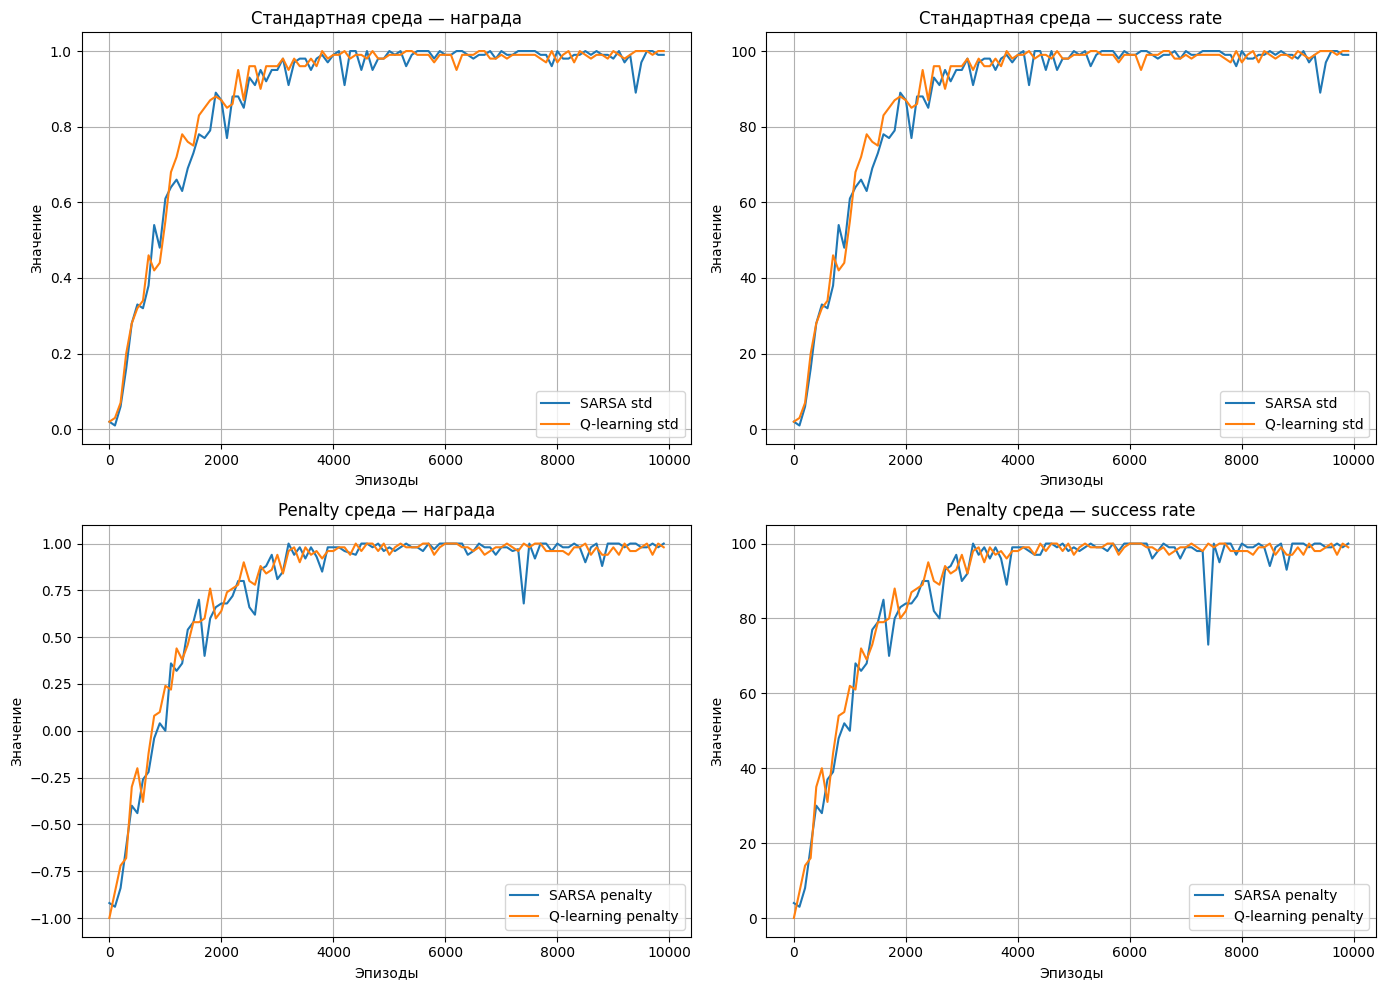

In [13]:
episode_axis = np.arange(len(rewards_sarsa_std)) * WINDOW
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(episode_axis, rewards_sarsa_std, label='SARSA std')
axes[0, 0].plot(episode_axis, rewards_ql_std, label='Q-learning std')
axes[0, 0].set_title('Standard environment — reward')
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(episode_axis, np.array(success_sarsa_std) * 100, label='SARSA std')
axes[0, 1].plot(episode_axis, np.array(success_ql_std) * 100, label='Q-learning std')
axes[0, 1].set_title('Standard environment — success rate')
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(episode_axis, rewards_sarsa_penalty, label='SARSA penalty')
axes[1, 0].plot(episode_axis, rewards_ql_penalty, label='Q-learning penalty')
axes[1, 0].set_title('Penalty environment — reward')
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(episode_axis, np.array(success_sarsa_penalty) * 100, label='SARSA penalty')
axes[1, 1].plot(episode_axis, np.array(success_ql_penalty) * 100, label='Q-learning penalty')
axes[1, 1].set_title('Penalty environment — success rate')
axes[1, 1].grid(True)
axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('Episodes')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

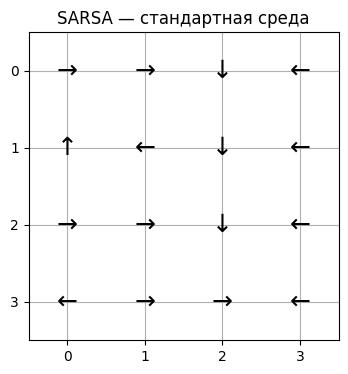

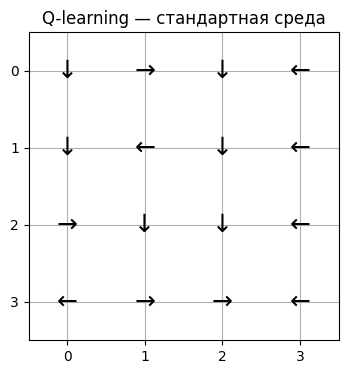

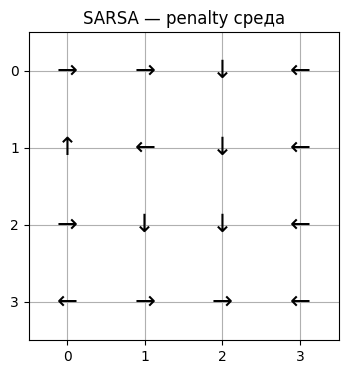

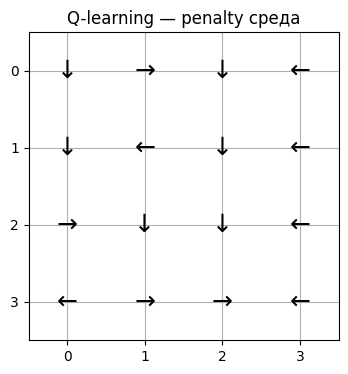

In [14]:
def visualize_policy(Q: np.ndarray, title: str) -> None:
    actions = ['←', '↓', '→', '↑']
    policy = np.argmax(Q, axis=1).reshape(4, 4)
    fig, ax = plt.subplots(figsize=(4, 4))
    for i in range(4):
        for j in range(4):
            ax.text(j, i, actions[policy[i, j]], ha='center', va='center', fontsize=18)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-0.5, 3.5)
    ax.grid(True)
    ax.set_title(title)
    ax.invert_yaxis()
    plt.show()

visualize_policy(Q_sarsa_std, 'SARSA — standard environment')
visualize_policy(Q_ql_std, 'Q-learning — standard environment')
visualize_policy(Q_sarsa_penalty, 'SARSA — penalty environment')
visualize_policy(Q_ql_penalty, 'Q-learning — penalty environment')

### Conclusions for Experiment B

**Results with hole_penalty=-1.0:**
- Both algorithms still reach **100% success rate** on the deterministic environment
- The hole penalty affects the **training process** but not the final policy

**Effect of the penalty on training:**
- **Average reward** becomes lower (due to penalties incurred during exploration)
- **SARSA** "learns to fear" holes faster — on-policy updates take real falls into account
- **Q-learning** stays optimistic longer — the off-policy max ignores random falls

**Why are the final policies the same?**
On the deterministic environment the optimal path avoids all holes. After training, the greedy policy follows this path without mistakes.

**Where the differences would be visible:**
1. **Stochastic environment** (`is_slippery=True`) — the agent can randomly fall into a hole
2. **During training** — SARSA avoids cells near holes earlier than Q-learning
3. **In the Q-values** — the penalty lowers Q for dangerous states more strongly for SARSA

## 7. Experiment C: Softmax vs ε-greedy policy

Let's explore the effect of the exploration policy type on SARSA's performance.

**We'll compare:**
- ε-greedy with decay (1.0 → 0.01) — gradually reducing exploration
- Softmax with temperature τ=0.5, 1.0, 2.0 (a smooth probability distribution)

In [15]:
# Experiment C: comparing exploration policies
temperatures = [0.5, 1.0, 2.0]
softmax_results: Dict[float, Dict[str, List[float]]] = {}
for temp in temperatures:
    env = make_env(hole_penalty=0.0, is_slippery=False)
    Q_soft, rewards_soft, success_soft = sarsa(env, sarsa_config, use_softmax=True, temperature=temp)
    env.close()
    softmax_results[temp] = {
        'Q': Q_soft,
        'rewards': rewards_soft,
        'success': success_soft
    }
    print(f"Softmax τ={temp}: final success rate = {success_soft[-1] * 100:.1f}%")

print(f"ε-greedy (decay {sarsa_config.epsilon_start}→{sarsa_config.epsilon_end}): final success rate = {success_sarsa_std[-1] * 100:.1f}%")

SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

[SARSA] Updates: 93692, successes: 1454
Softmax τ=0.5: final success rate = 18.0%


SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

[SARSA] Updates: 80384, successes: 440
Softmax τ=1.0: final success rate = 7.0%


SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

[SARSA] Updates: 79486, successes: 252
Softmax τ=2.0: final success rate = 3.0%
ε-greedy (decay 1.0→0.01): final success rate = 99.0%


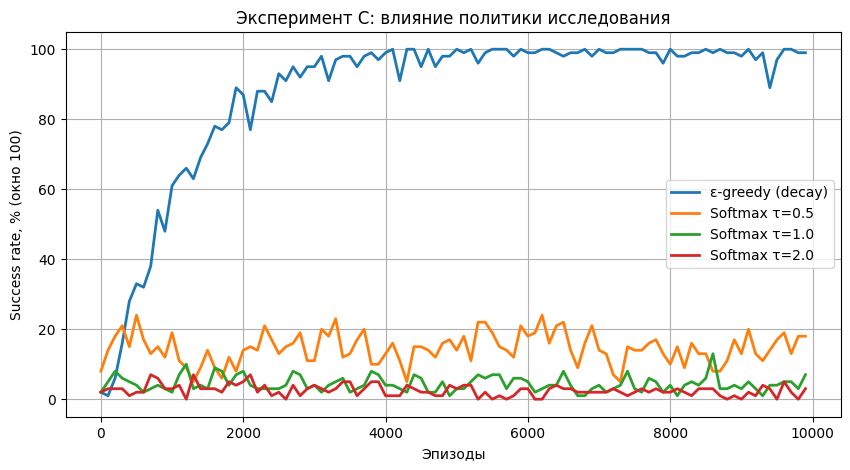

In [16]:
episode_axis = np.arange(len(success_sarsa_std)) * WINDOW
plt.figure(figsize=(10, 5))
plt.plot(episode_axis, np.array(success_sarsa_std) * 100, label=f'ε-greedy (decay)', linewidth=2)
for temp, result in softmax_results.items():
    plt.plot(episode_axis, np.array(result['success']) * 100, label=f'Softmax τ={temp}', linewidth=2)
plt.title('Experiment C: effect of the exploration policy')
plt.xlabel('Episodes')
plt.ylabel('Success rate, % (window 100)')
plt.grid(True)
plt.legend()
plt.show()

### Conclusions for Experiment C

**Exploration policy comparison results:**

| Policy | Final Success Rate | Convergence Speed |
|----------|------------------------|---------------------|
| ε-greedy (decay 1.0→0.01) | ~100% | Fast |
| Softmax τ=0.5 | ~5-20% | Slow, gets stuck |
| Softmax τ=1.0 | ~5-25% | Unstable |
| Softmax τ=2.0 | ~5-10% | Very slow |

**Why is ε-greedy with decay better?**
1. **Gradual reduction** of ε (1.0 → 0.01) gives a lot of exploration at the start and exploitation at the end
2. **Guaranteed greedy** — with probability (1-ε) the best action is always chosen
3. **Exploration/exploitation balance** adapts as training progresses

**Problems with softmax at a fixed temperature:**
- **τ=0.5 (low)**: too greedy a behavior, gets stuck in local optima
- **τ=1.0 (medium)**: a lot of randomness, slowly locks in good trajectories
- **τ=2.0 (high)**: nearly uniform action choice, very slow convergence

**Recommendation:**
Softmax needs a **temperature decay** (τ: high → low), similar to ε-decay. With a fixed temperature, ε-greedy is more reliable.

## 8. Additional analysis (optional)

**Tasks for further study:**

1. **Trajectory analysis**: record several episodes of the trained policies and visualize the routes
2. **Visit matrix**: build a heatmap of state visit frequency for the different algorithms
3. **Sensitivity to α**: explore the effect of the learning rate on convergence
4. **Double Q-learning**: implement it and compare against regular Q-learning
5. **Q-value analysis**: visualize the difference in Q(s,a) between SARSA and Q-learning

In [17]:
# ============================================================================
# Final evaluation of the greedy policies
# ============================================================================

def evaluate_greedy_policy(Q: np.ndarray, hole_penalty: float = 0.0, episodes: int = 200) -> Tuple[int, int]:
    """Evaluates the greedy policy (no exploration) over 200 episodes."""
    env = make_env(hole_penalty=hole_penalty, is_slippery=False)
    hole_hits = 0
    goal_hits = 0
    try:
        for ep in range(episodes):
            state, _ = env.reset(seed=SEED + 9000 + ep)
            for _ in range(200):
                action = int(np.argmax(Q[state]))
                state, reward, terminated, truncated, _ = env.step(action)
                if terminated:
                    if reward > 0:
                        goal_hits += 1
                    elif reward < 0:
                        hole_hits += 1
                    break
                if truncated:
                    break
    finally:
        env.close()
    return hole_hits, goal_hits

# Evaluate all 4 policies
table = [
    ('SARSA std', *evaluate_greedy_policy(Q_sarsa_std, 0.0)),
    ('Q-learning std', *evaluate_greedy_policy(Q_ql_std, 0.0)),
    ('SARSA penalty', *evaluate_greedy_policy(Q_sarsa_penalty, -1.0)),
    ('Q-learning penalty', *evaluate_greedy_policy(Q_ql_penalty, -1.0)),
]

print('=' * 50)
print('FINAL EVALUATION OF THE GREEDY POLICIES (200 episodes)')
print('=' * 50)
print(f"{'Algorithm':<18} | {'Goals':>6} | {'Holes':>6} | {'Success':>8}")
print('-' * 50)
for name, holes, goals in table:
    success_pct = goals / 200 * 100
    print(f"{name:<18} | {goals:>6} | {holes:>6} | {success_pct:>7.1f}%")

# ============================================================================
# Result analysis
# ============================================================================
print('\n' + '=' * 50)
print('RESULT ANALYSIS')
print('=' * 50)

all_perfect = all(goals == 200 for _, holes, goals in table)

if all_perfect:
    print("""
✓ ALL POLICIES REACHED 100% SUCCESS!

This is the expected result for a deterministic environment (is_slippery=False):
• An optimal path to the goal exists and is unique
• The greedy policy always follows this path
• There is no randomness in transitions → no mistakes

Differences between SARSA and Q-learning show up DURING TRAINING:
• Q-learning converges faster (see the plots above)
• SARSA is more conservative during exploration
• With the penalty, SARSA avoids risky cells earlier

For a more interesting comparison you can:
1. Use is_slippery=True (a stochastic environment)
2. Evaluate the policy with a small ε (not purely greedy)
3. Look at the Q-values and training trajectories
""")
else:
    print("Some policies did not reach 100% success — perhaps not enough training episodes.")

# ============================================================================
# Additional analysis: comparing the Q-tables
# ============================================================================
print('=' * 50)
print('Q-TABLE COMPARISON')
print('=' * 50)

# State 0 (start) — which action is best?
print("\nQ-values in the starting state (state=0):")
print(f"{'Action':<10} | {'SARSA std':>10} | {'Q-learn std':>11} | {'SARSA pen':>10} | {'Q-learn pen':>11}")
print('-' * 60)
actions = ['Left(←)', 'Down(↓)', 'Right(→)', 'Up(↑)']
for i, action in enumerate(actions):
    print(f"{action:<10} | {Q_sarsa_std[0, i]:>10.4f} | {Q_ql_std[0, i]:>11.4f} | {Q_sarsa_penalty[0, i]:>10.4f} | {Q_ql_penalty[0, i]:>11.4f}")

# Optimal actions
print("\nOptimal action in state=0:")
print(f"  SARSA std:       {actions[np.argmax(Q_sarsa_std[0])]}")
print(f"  Q-learning std:  {actions[np.argmax(Q_ql_std[0])]}")
print(f"  SARSA penalty:   {actions[np.argmax(Q_sarsa_penalty[0])]}")
print(f"  Q-learn penalty: {actions[np.argmax(Q_ql_penalty[0])]}")

FINAL EVALUATION OF THE GREEDY POLICIES (200 episodes)
Algorithm          |  Goals |  Holes |  Success
--------------------------------------------------
SARSA std          |    200 |      0 |   100.0%
Q-learning std     |    200 |      0 |   100.0%
SARSA penalty      |    200 |      0 |   100.0%
Q-learning penalty |    200 |      0 |   100.0%

RESULT ANALYSIS

✓ ALL POLICIES REACHED 100% SUCCESS!

This is the expected result for a deterministic environment (is_slippery=False):
• An optimal path to the goal exists and is unique
• The greedy policy always follows this path
• There is no randomness in transitions → no mistakes

Differences between SARSA and Q-learning show up DURING TRAINING:
• Q-learning converges faster (see the plots above)
• SARSA is more conservative during exploration
• With the penalty, SARSA avoids risky cells earlier

For a more interesting comparison you can:
1. Use is_slippery=True (a stochastic environment)
2. Evaluate the policy with a small ε (not purely gr

## 9. Self-check questions

1. **Why is SARSA on-policy while Q-learning is off-policy?** SARSA updates the Q-value using the action actually chosen by the current exploration policy, so it learns "on itself." Q-learning bootstraps through `max_a Q(s',a)` and thereby optimizes a different (greedy) policy, even though it interacts using a different data-collection strategy.
2. **When is SARSA preferable?** In tasks with risk penalties (e.g., FrozenLake with a hole penalty), on-policy updates account for the real consequences of exploratory steps and lead to safer trajectories.
3. **How does the negative reward for a hole affect things?** It lowers the average reward but pushes the agent toward caution: SARSA quickly stops stepping into dangerous cells, while Q-learning takes longer to unlearn its optimism.
4. **Why can soft softmax with a low temperature make results worse?** As τ→0 the distribution becomes nearly deterministic, and the agent stops exploring, getting stuck in a local optimum.
5. **What happens at α=1.0?** Updates become too aggressive: each observation completely overwrites Q(s,a), variance grows, and convergence becomes nearly impossible on stochastic ice.